# Testing Strategies: Analysis

Comparing training strategies with `hidden_cell_fraction=0.5` and `weight_perturbation_variance=0.5`.

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import toml
import torch
import zarr

sys.path.insert(
    0,
    "/tachyon/groups/scratch/gzenke/bedfrory/teacher-student/hidden-activity/scripts",
)

from utils.reproducibility import load_experiment_config
from analysis import run_recurrent_inference, interleave_spike_trains
from visualization import (
    use_project_style,
    plot_spike_trains,
    plot_firing_rate_scatter,
    plot_sf_bar_chart,
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
)
from visualization.scaling_factors import SF_PATHWAYS

use_project_style()

In [2]:
# Paths
base_dir = load_experiment_config("em-algorithm.toml")["output_dir"].parent

# All possible procedures
all_procedures = {
    "em-algorithm": "EM Algorithm",
    "fully-recurrent": "Fully Recurrent",
    "ignore-hidden": "Ignore Hidden",
    "visible-driven": "Visible-Driven",
}

# Filter to only procedures whose output directories exist
procedures = {}
for key, label in all_procedures.items():
    exp_dir = base_dir / key
    if exp_dir.exists():
        procedures[key] = label
    else:
        print(f"Skipping {label} (dir not found: {exp_dir.name})")

experiments = {label: base_dir / key for key, label in procedures.items()}

# Load procedure metrics and compute chunks_per_epoch from saved parameters
proc_metrics = {}
CHUNKS_PER_EPOCH = {}
for key, label in procedures.items():
    exp_dir = base_dir / key
    csv_path = exp_dir / "training_metrics.csv"
    if csv_path.exists():
        proc_metrics[key] = pd.read_csv(csv_path)

    # Read chunk_size from snapshotted parameters, total timesteps from zarr
    params_path = exp_dir / "parameters.toml"
    if params_path.exists():
        params = toml.load(params_path)
        chunk_size = params["simulation"]["chunk_size"]
        zarr_path = exp_dir / "inputs" / "spike_data.zarr"
        if zarr_path.exists():
            z = zarr.open_group(zarr_path, mode="r")
            total_timesteps = z["output_spikes"].shape[1]
            CHUNKS_PER_EPOCH[key] = total_timesteps // chunk_size

print(f"Chunks per data epoch: {CHUNKS_PER_EPOCH}")

Skipping Ignore Hidden (dir not found: ignore-hidden)
Chunks per data epoch: {'em-algorithm': 60, 'fully-recurrent': 150, 'visible-driven': 93}


In [3]:
# Device for inference
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Inference settings (fixed across all procedures)
CHUNK_SIZE = 250
N_BURNIN_CHUNKS = 10  # 2.5s
N_ANALYSIS_CHUNKS = 40  # 10s

# Colours for procedures
PROC_COLORS = {
    "em-algorithm": "C0",
    "fully-recurrent": "C4",
    "ignore-hidden": "C8",
    "visible-driven": "C9",
}

# Strategies to compare side-by-side
KEYS_COMPARE = ["em-algorithm", "ignore-hidden"]

### Scaling Factor Trajectories

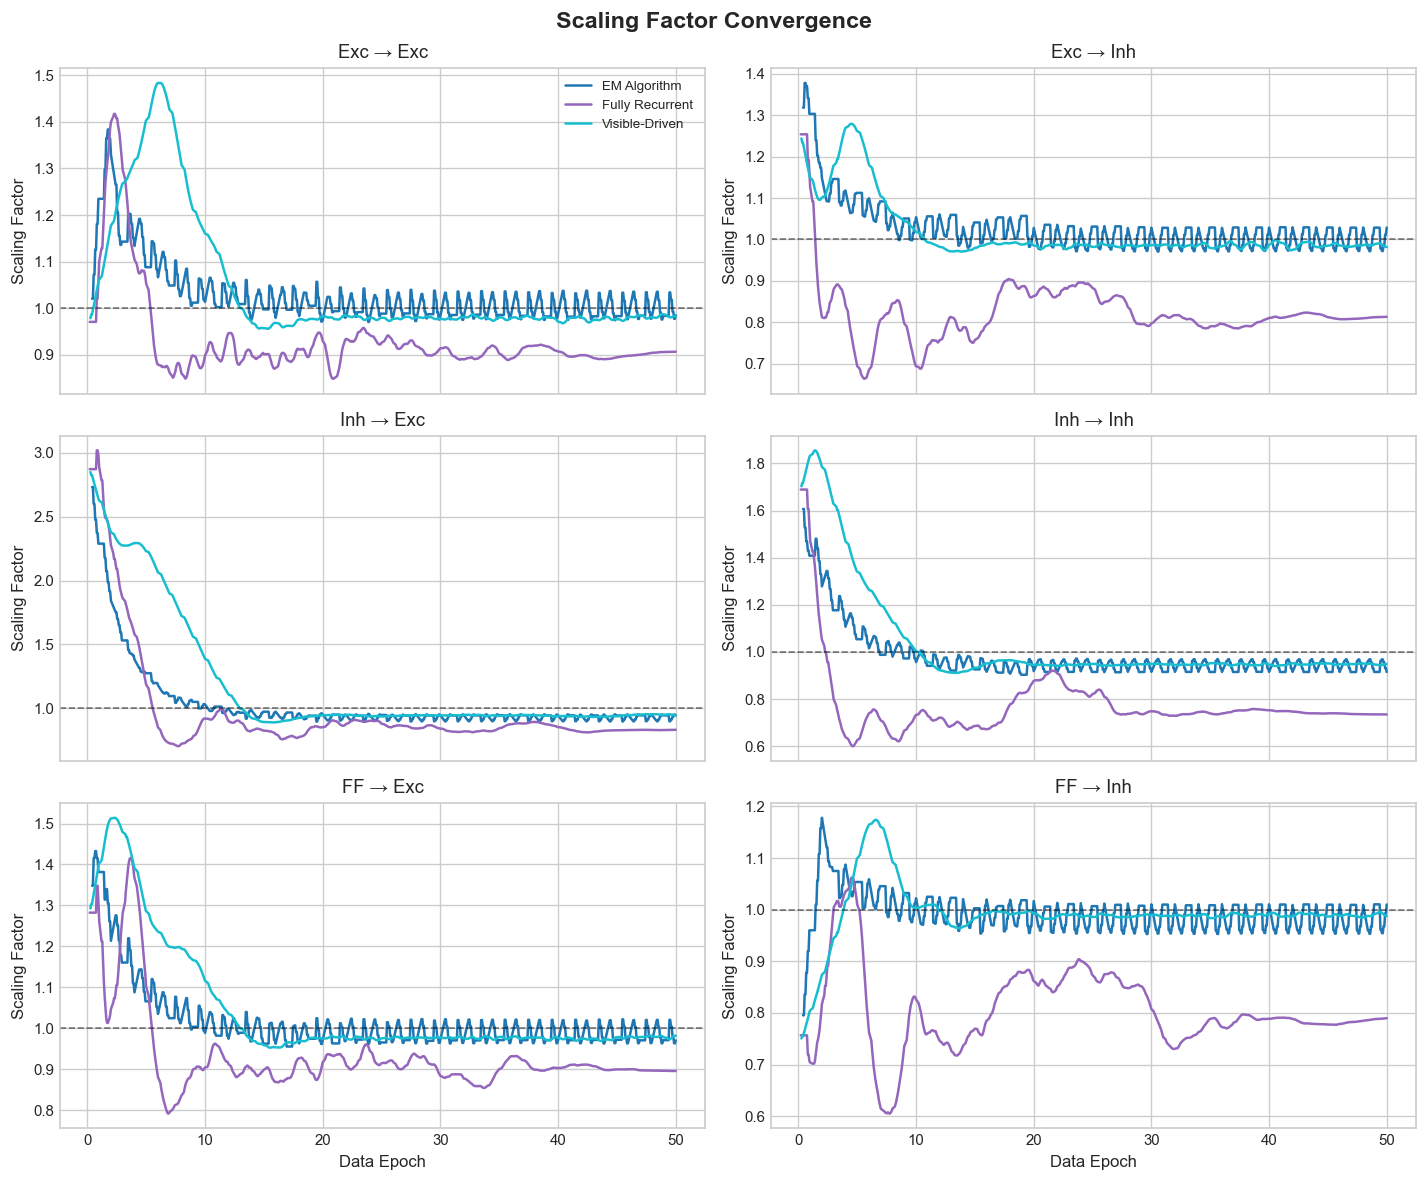

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

for idx, (key, title) in enumerate(SF_PATHWAYS):
    ax = axes.flat[idx]
    col = f"scaling_factors/{key}_value"

    for name, df in proc_metrics.items():
        if col not in df.columns:
            continue
        cpe = CHUNKS_PER_EPOCH.get(name, 50)
        ax.plot(
            df["epoch"] / cpe,
            df[col],
            color=PROC_COLORS[name],
            linewidth=1.5,
            label=procedures[name],
        )

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Scaling Factor")
    if idx >= 4:
        ax.set_xlabel("Data Epoch")
    if idx == 0:
        ax.legend(loc="best", fontsize=8)

plt.suptitle("Scaling Factor Convergence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Final Scaling Factors

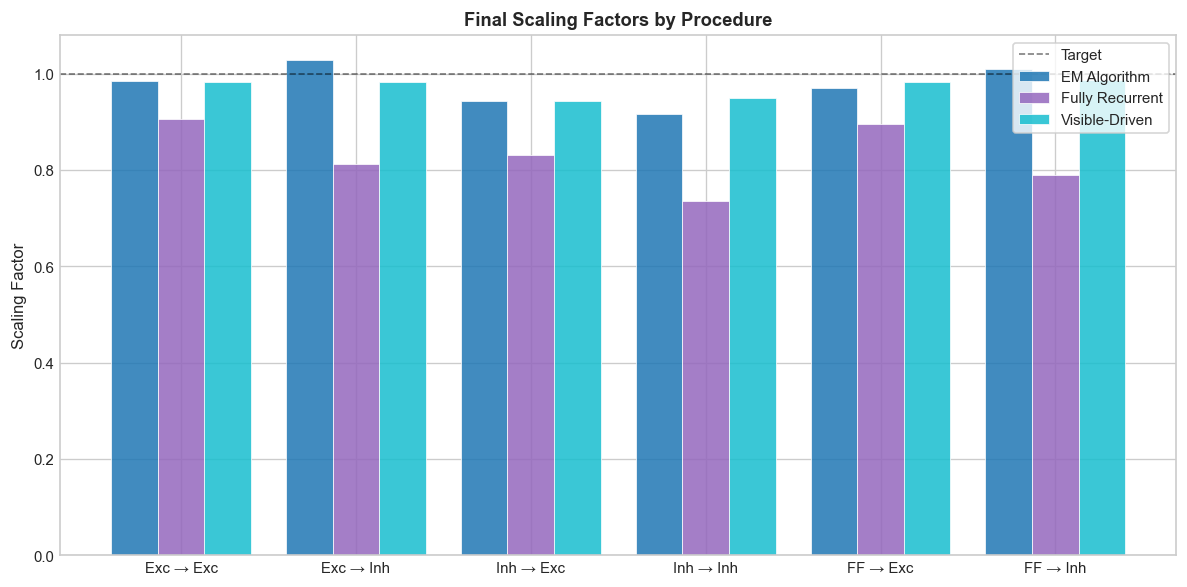

In [5]:
sf_data = {}
for name, df in proc_metrics.items():
    final = df.iloc[-1]
    sf_data[procedures[name]] = {
        k: float(final[f"scaling_factors/{k}_value"]) for k, _ in SF_PATHWAYS
    }

plot_sf_bar_chart(
    sf_data,
    condition_labels=[procedures[name] for name in proc_metrics],
    condition_colors=[PROC_COLORS[name] for name in proc_metrics],
    figsize=(10, 5),
    title="Final Scaling Factors by Procedure",
)
plt.show()

### Loss Trajectories

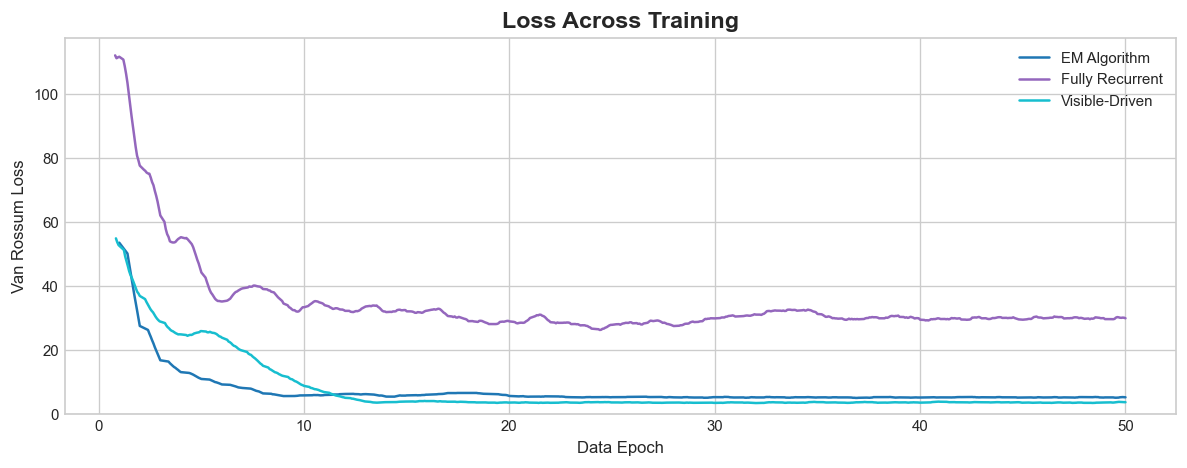

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

smooth_window = 10

for name, df in proc_metrics.items():
    loss_col = "van_rossum_loss" if "van_rossum_loss" in df.columns else "total_loss"
    cpe = CHUNKS_PER_EPOCH.get(name, 50)
    smoothed = df[loss_col].rolling(smooth_window).mean()
    ax.plot(
        df["epoch"] / cpe,
        smoothed,
        color=PROC_COLORS[name],
        linewidth=1.5,
        label=procedures[name],
    )

ax.set_xlabel("Data Epoch")
ax.set_ylabel("Van Rossum Loss")
ax.set_title("Loss Across Training", fontsize=14, fontweight="bold")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

### Firing Rates (Visible and Hidden)

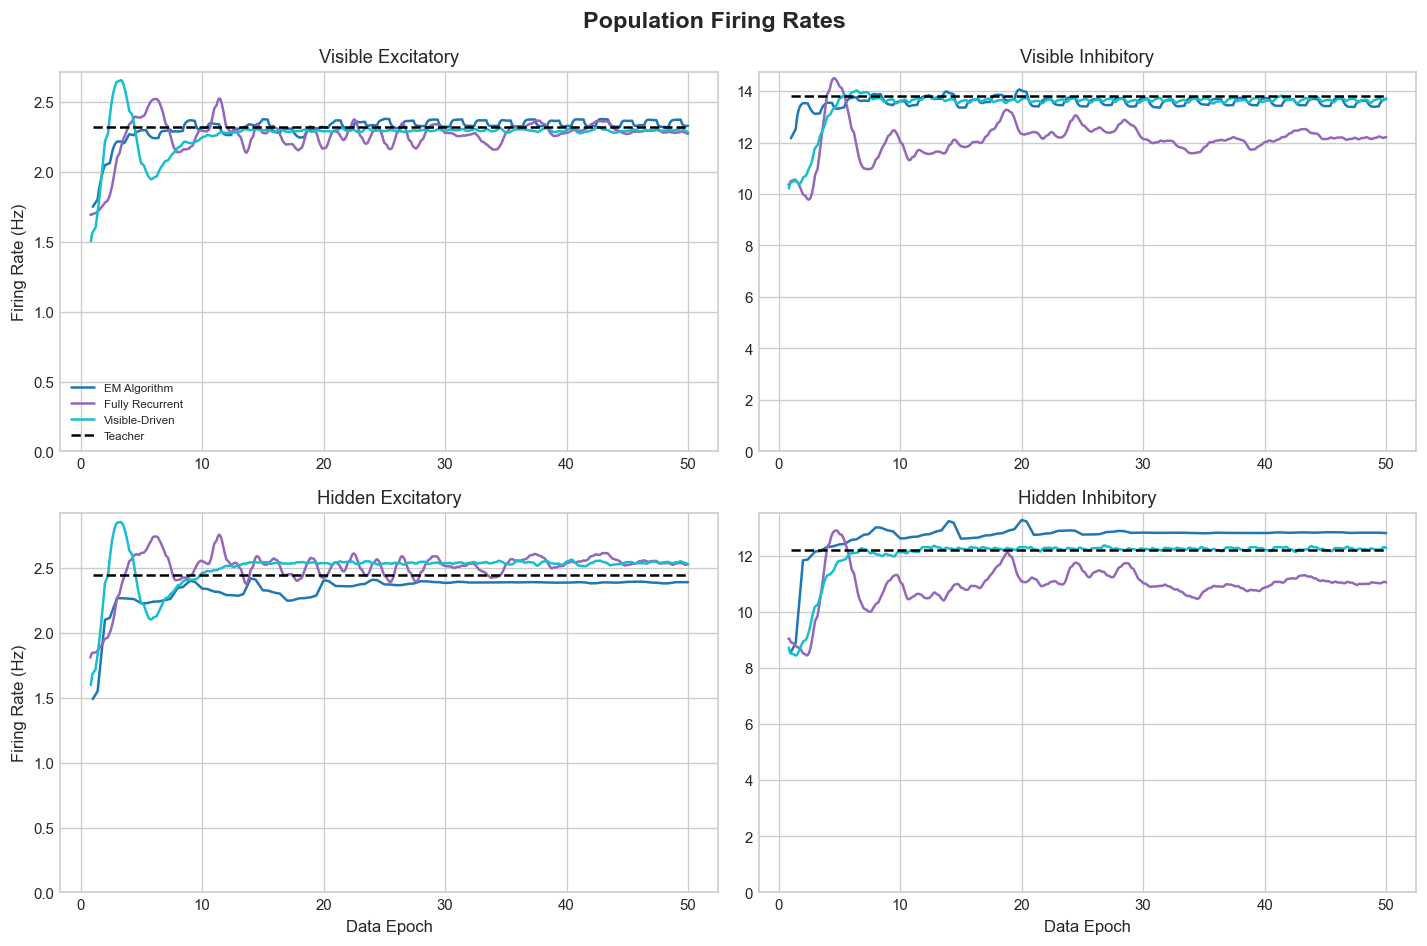

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

smooth_window = 10

fr_grid = [
    (0, 0, "visible", "excitatory", "Visible Excitatory"),
    (0, 1, "visible", "inhibitory", "Visible Inhibitory"),
    (1, 0, "hidden", "excitatory", "Hidden Excitatory"),
    (1, 1, "hidden", "inhibitory", "Hidden Inhibitory"),
]

for row, col, visibility, cell_type, title in fr_grid:
    ax = axes[row, col]
    student_col = f"firing_rate/student_{visibility}_{cell_type}_mean"
    teacher_col = f"firing_rate/teacher_{visibility}_{cell_type}_mean"

    for name, df in proc_metrics.items():
        if student_col not in df.columns:
            continue
        cpe = CHUNKS_PER_EPOCH.get(name, 50)
        x = df["epoch"] / cpe
        mean = df[student_col].rolling(smooth_window).mean()
        ax.plot(x, mean, color=PROC_COLORS[name], linewidth=1.5, label=procedures[name])

    # Teacher reference (from first procedure that has it)
    for name, df in proc_metrics.items():
        if teacher_col in df.columns:
            cpe = CHUNKS_PER_EPOCH.get(name, 50)
            x = df["epoch"] / cpe
            t_mean = df[teacher_col].rolling(smooth_window).mean()
            ax.plot(
                x, t_mean, color="black", linestyle="--", linewidth=1.5, label="Teacher"
            )
            break

    ax.set_title(title)
    ax.set_ylim(0, None)
    if row == 1:
        ax.set_xlabel("Data Epoch")
    if col == 0:
        ax.set_ylabel("Firing Rate (Hz)")
    if row == 0 and col == 0:
        ax.legend(fontsize=7)

plt.suptitle("Population Firing Rates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Per-Neuron Firing Rates (Inference with Final Scaling Factors)

For each experiment, run E-step and M-step inference using the final learned scaling factors to get per-neuron firing rates for both hidden and visible neurons.

In [ ]:
def _find_best_checkpoint(exp_dir):
    """Find best checkpoint path, checking both direct and EM iteration layouts."""
    for name in ["checkpoint_best.pt", "checkpoint_latest.pt"]:
        p = exp_dir / "checkpoints" / name
        if p.exists():
            return p
    em_dirs = sorted(exp_dir.glob("em_iter_*"))
    if em_dirs:
        for name in ["checkpoint_best.pt", "checkpoint_latest.pt"]:
            p = em_dirs[-1] / "checkpoints" / name
            if p.exists():
                return p
    return None


def _load_sf_from_checkpoint(ckpt_path, target_sf_path, params_path):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    sd = ckpt["model_state_dict"]

    params = toml.load(params_path)
    ff_names = list(params["feedforward"]["cell_types"]["names"])
    rec_names = list(params["recurrent"]["cell_types"]["names"])
    n_ff = len(ff_names)
    n_rec = len(rec_names)

    def _collect(group):
        out = {}
        prefix = group + "."
        suffix = ".log_sf"
        for k, v in sd.items():
            kk = k.replace("_orig_mod.", "")
            if kk.startswith(prefix) and kk.endswith(suffix):
                pair_key = kk[len(prefix) : -len(suffix)]
                src, tgt = pair_key.split("__", 1)
                out[(src, tgt)] = float(torch.exp(v).item())
        return out

    ff_pairs = _collect("ff_projections")
    rec_pairs = _collect("rec_projections")

    targets = np.load(target_sf_path)["feedforward_scaling_factors"]
    target_ff_unique = targets[:n_ff, :]
    target_rec = targets[n_ff:, :]

    combined_input_names = ff_names + rec_names

    if ff_pairs and not rec_pairs:
        sf_full = np.ones((n_ff + n_rec, n_rec), dtype=np.float64)
        for (src, tgt), v in ff_pairs.items():
            sf_full[combined_input_names.index(src), rec_names.index(tgt)] = v
        sf_ff_unique = sf_full[:n_ff, :] / target_ff_unique
        sf_rec = sf_full[n_ff:, :] / target_rec
        raw = {"ff": sf_full, "rec": None}
    elif ff_pairs and rec_pairs:
        sf_ff_raw = np.ones((n_ff, n_rec), dtype=np.float64)
        for (src, tgt), v in ff_pairs.items():
            sf_ff_raw[ff_names.index(src), rec_names.index(tgt)] = v
        sf_rec_raw = np.ones((n_rec, n_rec), dtype=np.float64)
        for (src, tgt), v in rec_pairs.items():
            sf_rec_raw[rec_names.index(src), rec_names.index(tgt)] = v
        sf_ff_unique = sf_ff_raw / target_ff_unique
        sf_rec = sf_rec_raw / target_rec
        raw = {"ff": sf_ff_raw, "rec": sf_rec_raw}
    else:
        raise RuntimeError(
            f"No projection scaling factors found in checkpoint {ckpt_path}"
        )

    return sf_rec, sf_ff_unique, raw


def run_inference_for_procedure(key, exp_dir, device="cpu"):
    ckpt_path = _find_best_checkpoint(exp_dir)
    if ckpt_path is None:
        print(f"  Skipping {key}: no checkpoint found")
        return None

    params_path = exp_dir / "parameters.toml"
    cache_path = exp_dir / "inference_cache.npz"
    target_sf_path = exp_dir / "targets" / "target_scaling_factors.npz"
    sf_rec, sf_ff_unique, _ = _load_sf_from_checkpoint(
        ckpt_path, target_sf_path, params_path
    )

    return run_recurrent_inference(
        params_path,
        exp_dir,
        scaling_factors=sf_rec,
        scaling_factors_FF=sf_ff_unique,
        chunk_size=CHUNK_SIZE,
        n_burnin_chunks=N_BURNIN_CHUNKS,
        n_analysis_chunks=N_ANALYSIS_CHUNKS,
        cache_path=cache_path,
        device=device,
        desc=key,
    )

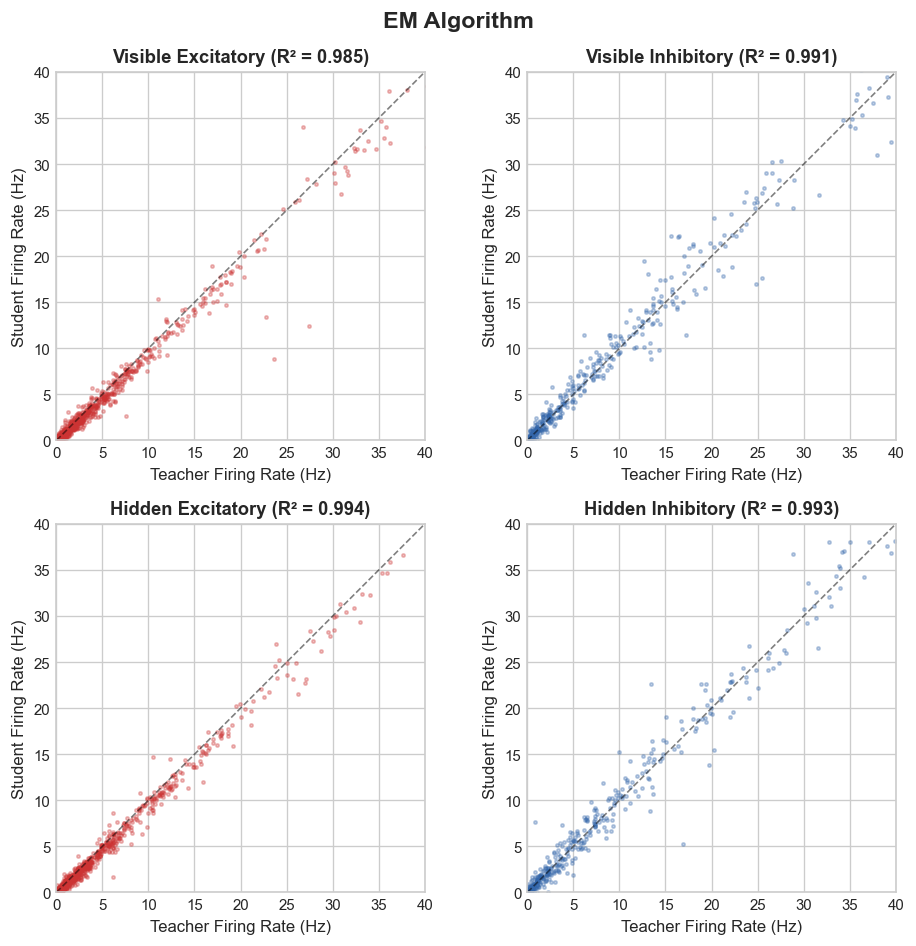

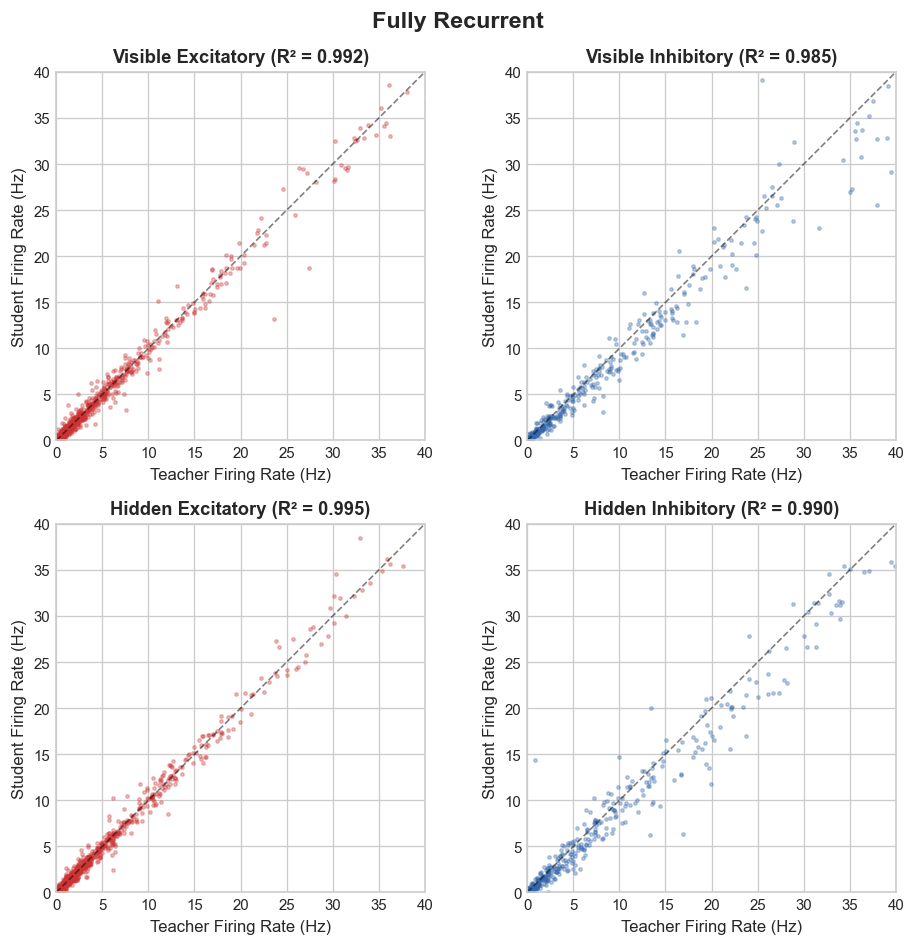

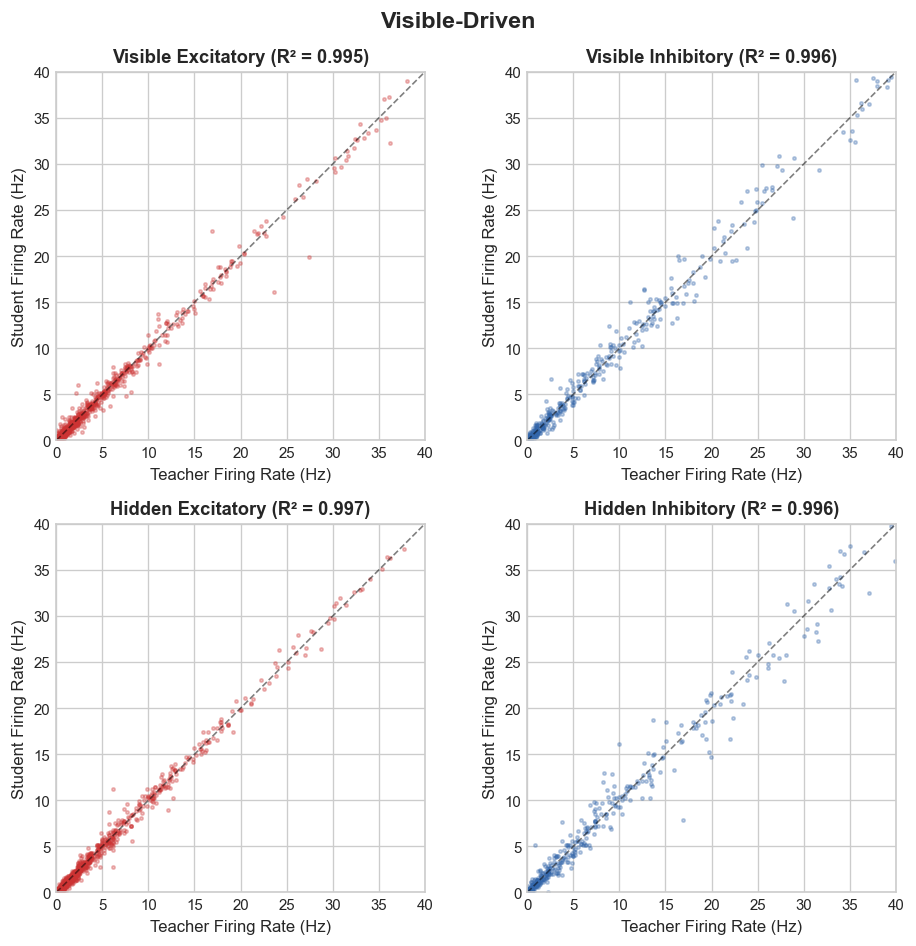

In [9]:
GROUP_NAMES = [
    "Visible Excitatory",
    "Visible Inhibitory",
    "Hidden Excitatory",
    "Hidden Inhibitory",
]
GROUP_COLORS = [EXCITATORY_COLOR, INHIBITORY_COLOR, EXCITATORY_COLOR, INHIBITORY_COLOR]
MAX_RATE = 40.0

# Load hidden/visible indices (shared across all procedures)
first_exp = next(base_dir / k for k in procedures if (base_dir / k).exists())
hidden_info = np.load(first_exp / "targets" / "hidden_neurons.npz")
vis_idx = hidden_info["visible_indices"]
hid_idx = hidden_info["hidden_indices"]

# Run inference for all procedures
all_data = {}
for key, label in procedures.items():
    try:
        data = run_inference_for_procedure(key, base_dir / key, DEVICE)
        if data is not None:
            all_data[key] = data
    except Exception as e:
        print(f"  Skipping {key} inference: {e}")

# Compute per-neuron firing rates
all_rates = {}
for key, data in all_data.items():
    dt = data["dt"]
    duration_s = data["teacher_spikes"].shape[0] * dt / 1000.0
    teacher_rates = data["teacher_spikes"].sum(axis=0) / duration_s
    student_rates = data["student_spikes"].sum(axis=0) / duration_s
    all_rates[key] = (
        teacher_rates[vis_idx],
        teacher_rates[hid_idx],
        student_rates[vis_idx],
        student_rates[hid_idx],
    )

# Plot firing rate scatter for all procedures
for key, label in procedures.items():
    if key not in all_rates:
        continue
    vis_teacher, hid_teacher, vis_student, hid_student = all_rates[key]
    ct = all_data[key]["cell_type_indices"]
    vis_ct = ct[vis_idx]
    hid_ct = ct[hid_idx]

    teacher = np.concatenate([vis_teacher, hid_teacher])
    student = np.concatenate([vis_student, hid_student])
    group = np.concatenate([vis_ct, hid_ct + 2])

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    plot_firing_rate_scatter(
        teacher,
        student,
        group,
        split_panels=True,
        axes=[axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]],
        cell_type_names=GROUP_NAMES,
        cell_type_colors=GROUP_COLORS,
        max_rate=MAX_RATE,
        marker_size=4,
        alpha=0.3,
    )
    fig.suptitle(label, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

### Spike Raster Comparisons

Teacher vs student spike trains for visible and hidden neurons, plotted separately.

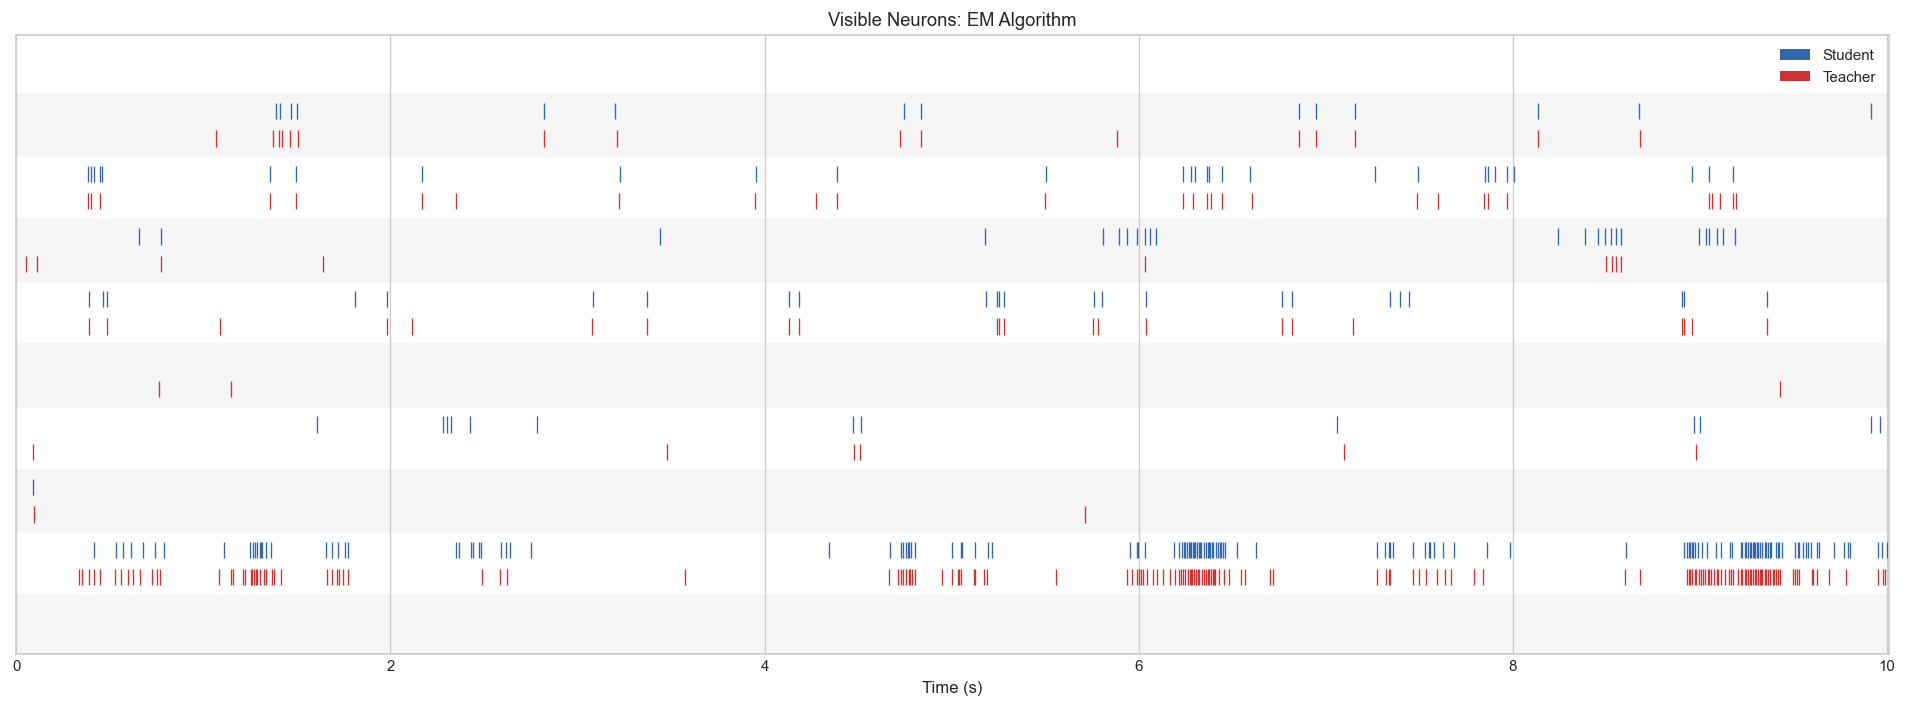

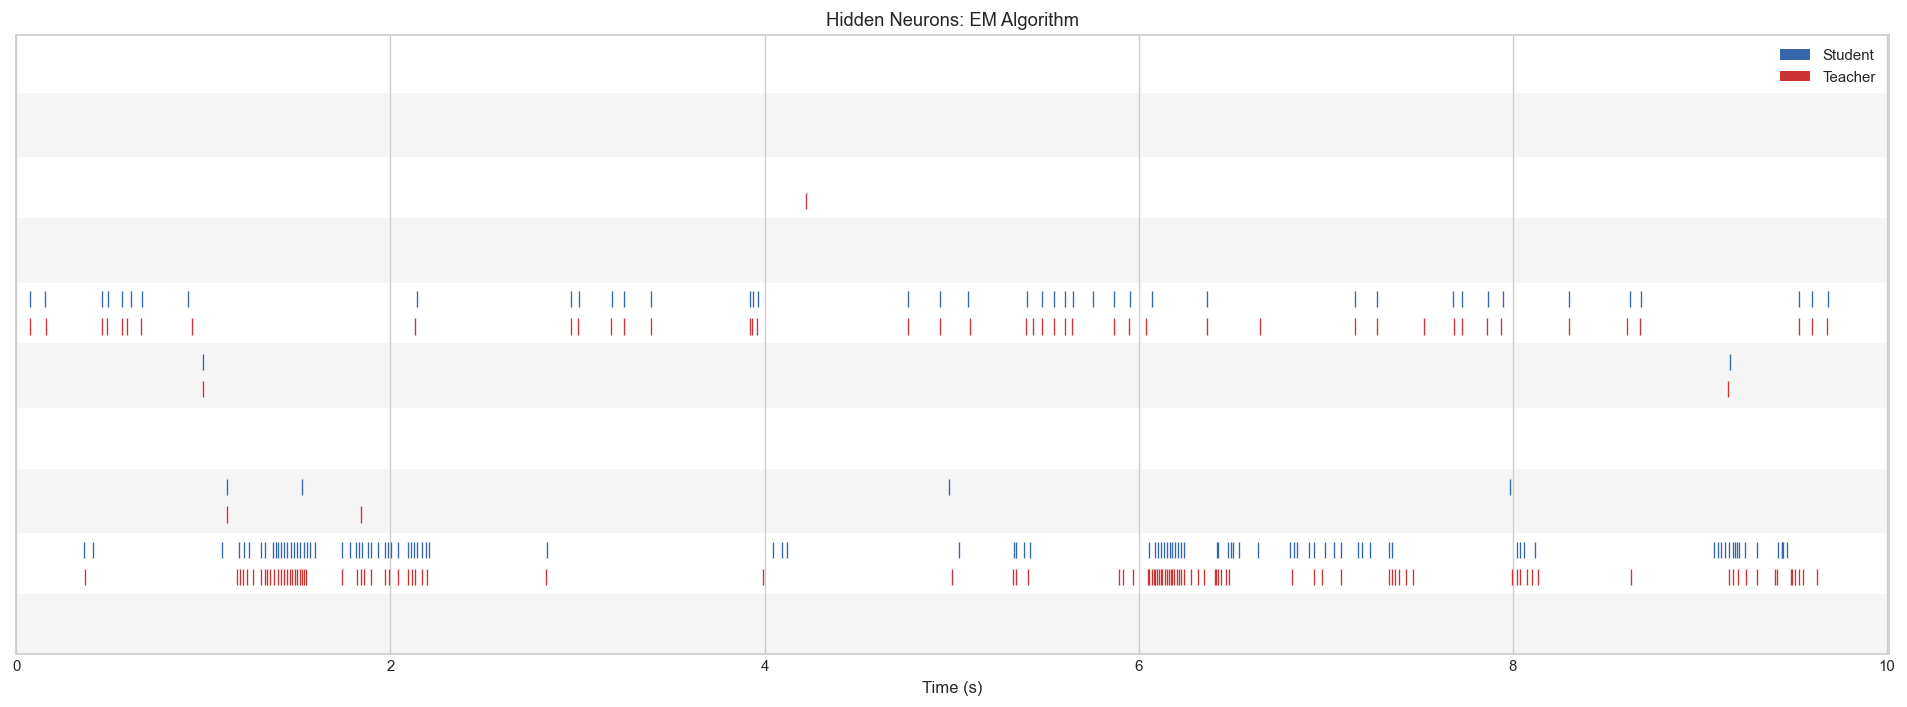

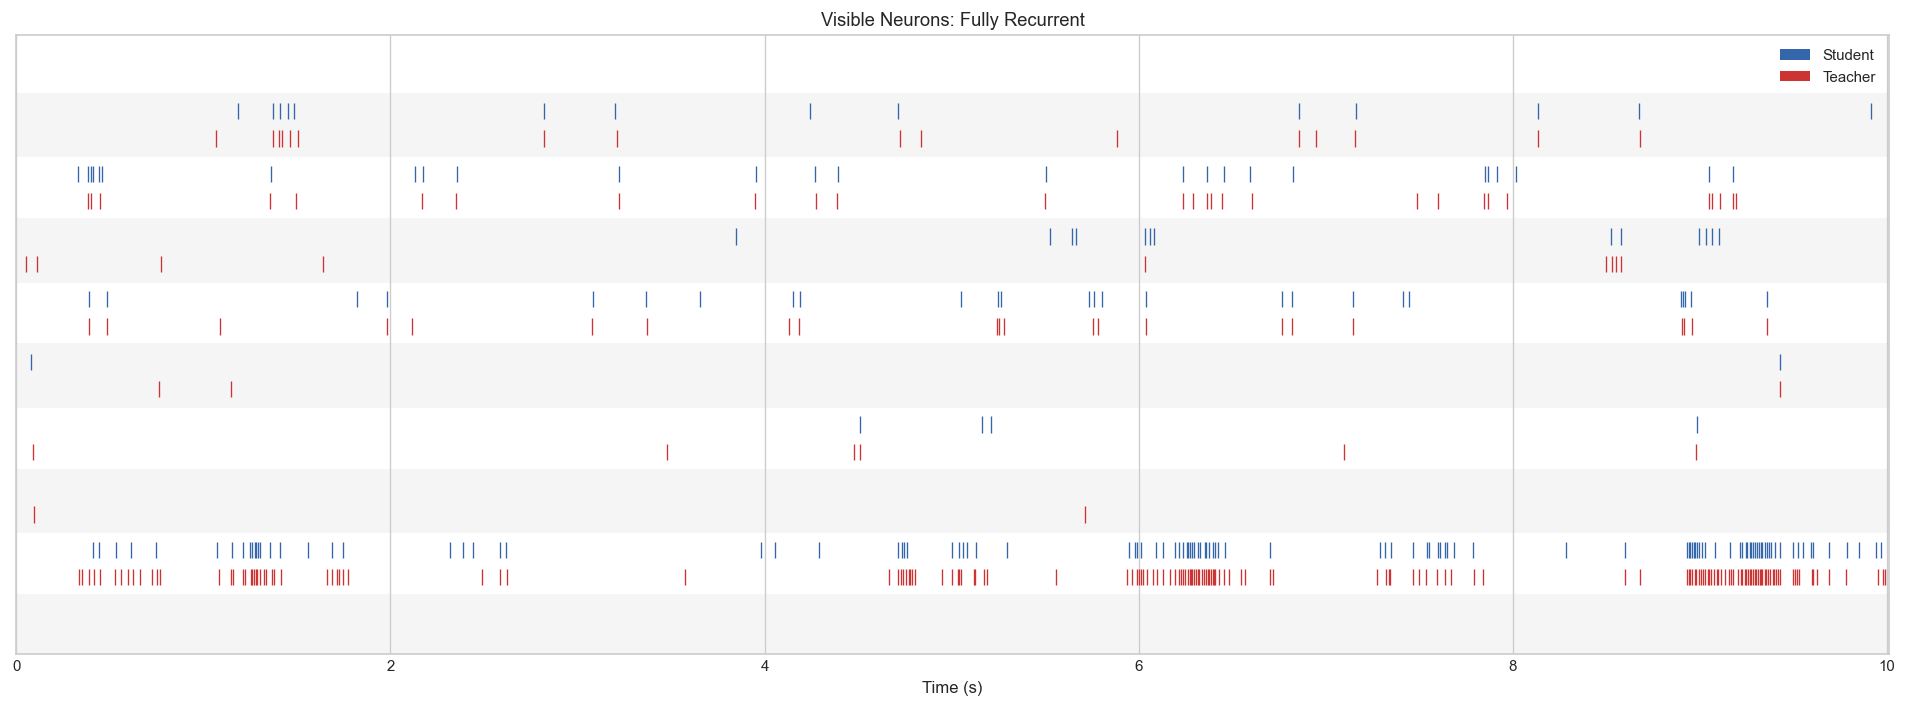

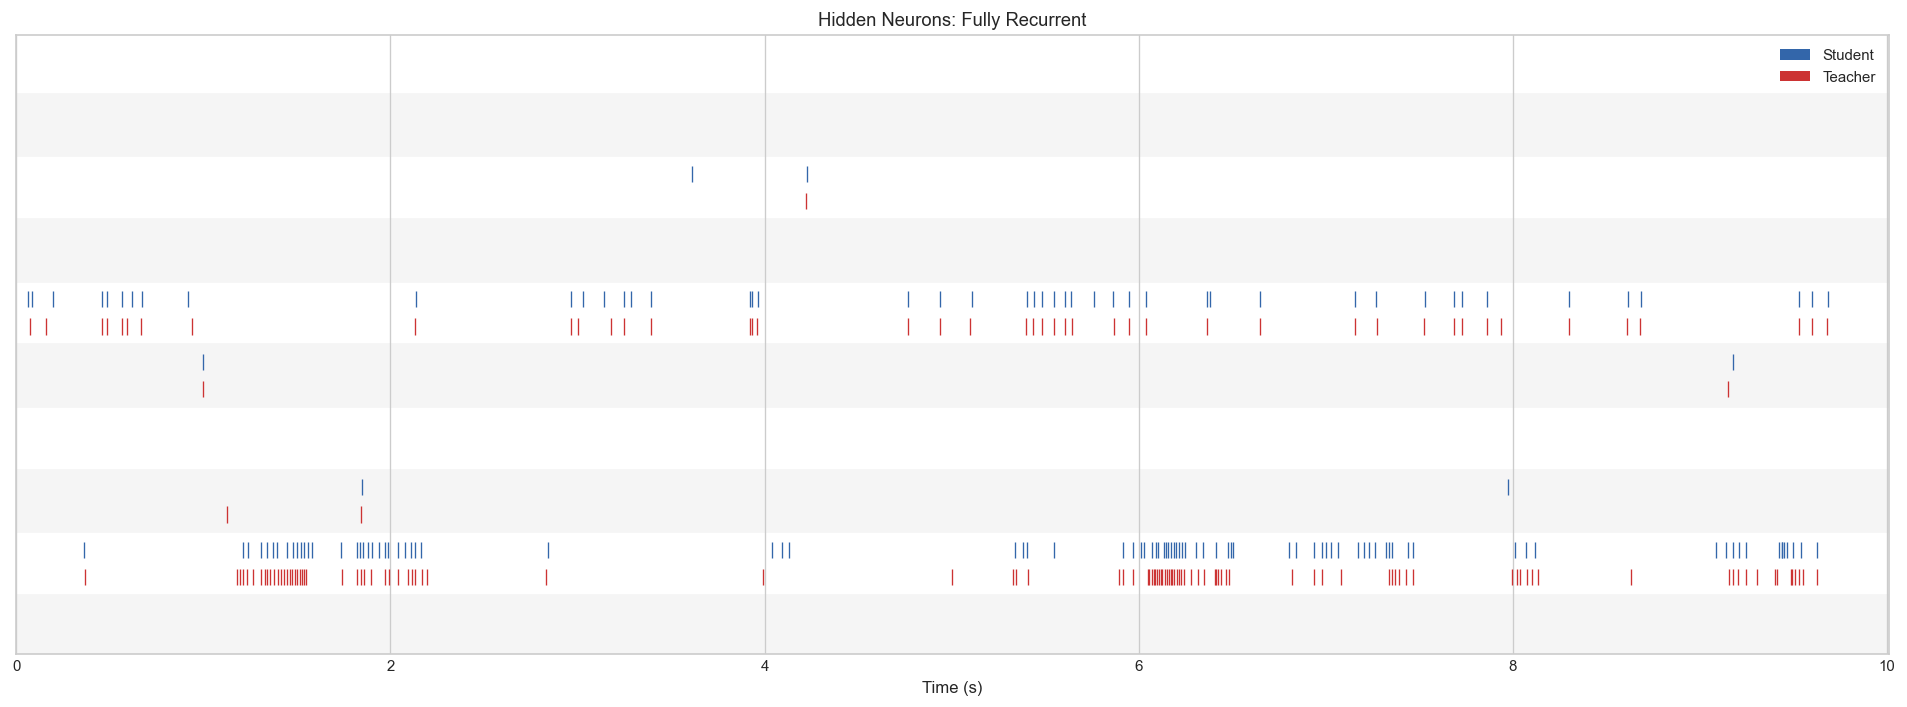

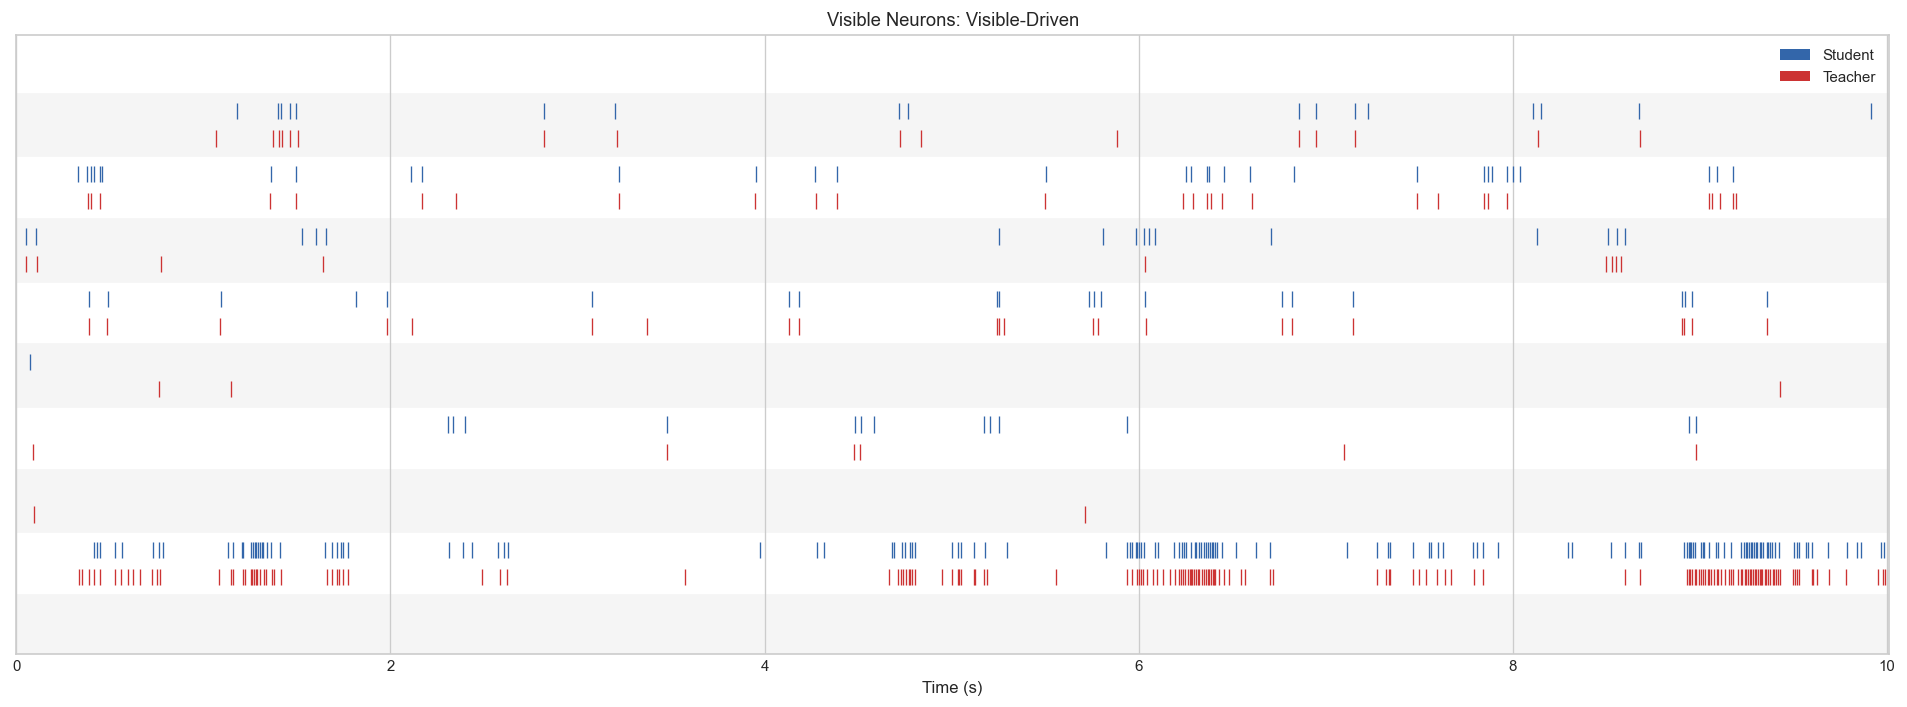

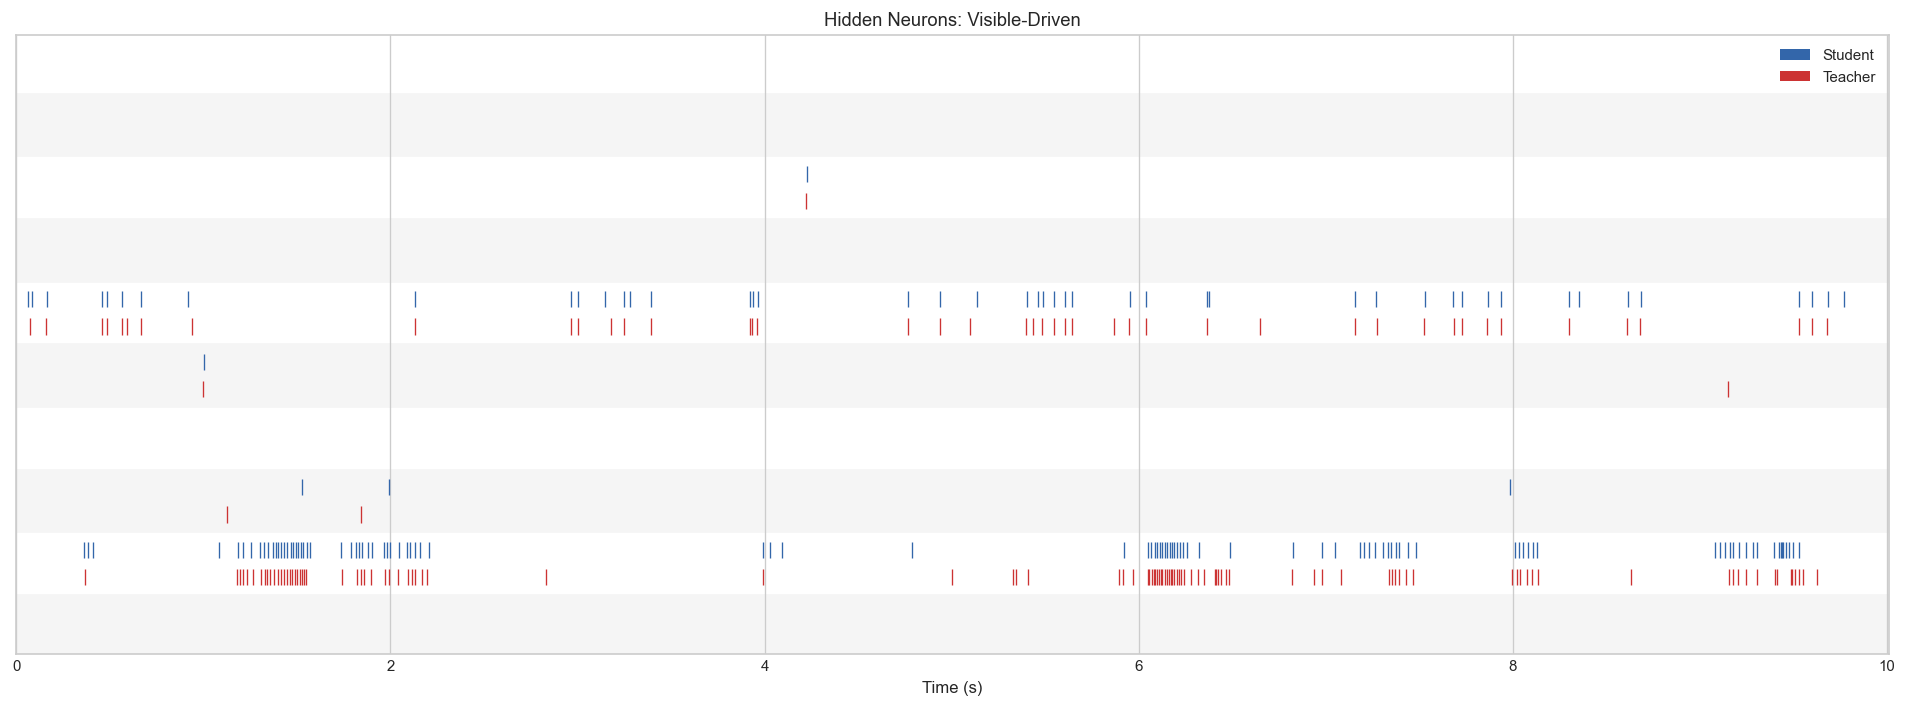

In [10]:
# Select neurons for raster display
N_NEURONS_SHOW = 10
rng = np.random.RandomState(42)
show_vis_cols = np.sort(rng.choice(len(vis_idx), N_NEURONS_SHOW, replace=False))
show_hid_cols = np.sort(rng.choice(len(hid_idx), N_NEURONS_SHOW, replace=False))

for key, label in procedures.items():
    if key not in all_data:
        continue
    data = all_data[key]
    teacher = data["teacher_spikes"]
    student = data["student_spikes"]

    for vis_type, cols in [("visible", show_vis_cols), ("hidden", show_hid_cols)]:
        idx = vis_idx if vis_type == "visible" else hid_idx
        t_slice = teacher[:, idx[cols]]
        s_slice = student[:, idx[cols]]

        interleaved, ct_idx = interleave_spike_trains(t_slice, s_slice)

        fig = plot_spike_trains(
            spikes=interleaved,
            dt=data["dt"],
            cell_type_indices=ct_idx,
            cell_type_names=["Teacher", "Student"],
            n_neurons_plot=2 * N_NEURONS_SHOW,
            n_compared=2,
            fraction=1.0,
            random_seed=None,
            title=f"{vis_type.title()} Neurons: {label}",
            figsize=(16, 6),
        )
        plt.show()

In [11]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")


def compute_fluctuations(spikes, dt, bin_ms=250):
    """Per-neuron std of binned firing rates (temporal variability)."""
    bin_size = int(bin_ms / dt)
    n_time, n_neurons = spikes.shape
    n_bins = n_time // bin_size
    trimmed = spikes[: n_bins * bin_size, :]
    binned = trimmed.reshape(n_bins, bin_size, n_neurons).sum(axis=1) / (
        bin_ms / 1000.0
    )
    return binned.std(axis=0)


# Build summary rows
rows = []
for name, df in proc_metrics.items():
    final = df.iloc[-1]
    sf_values = [final[f"scaling_factors/{k}_value"] for k, _ in SF_PATHWAYS]
    sf_arr = np.array(sf_values)

    row = {
        "Procedure": procedures[name],
        "Loss": final.get("van_rossum_loss", final.get("total_loss", float("nan"))),
        "Mean |SF-1|": np.mean(np.abs(sf_arr - 1.0)),
    }

    if name in all_data:
        data = all_data[name]
        dt = data["dt"]
        teacher = data["teacher_spikes"]
        student = data["student_spikes"]
        duration_s = teacher.shape[0] * dt / 1000.0

        t_rates = teacher.sum(axis=0) / duration_s
        s_rates = student.sum(axis=0) / duration_s
        t_fluct = compute_fluctuations(teacher, dt)
        s_fluct = compute_fluctuations(student, dt)

        row["R2 Rate (vis)"] = r_squared(t_rates[vis_idx], s_rates[vis_idx])
        row["R2 Rate (hid)"] = r_squared(t_rates[hid_idx], s_rates[hid_idx])
        row["R2 Fluct (vis)"] = r_squared(t_fluct[vis_idx], s_fluct[vis_idx])
        row["R2 Fluct (hid)"] = r_squared(t_fluct[hid_idx], s_fluct[hid_idx])
    else:
        for col in [
            "R2 Rate (vis)",
            "R2 Rate (hid)",
            "R2 Fluct (vis)",
            "R2 Fluct (hid)",
        ]:
            row[col] = float("nan")

    rows.append(row)

# Build and display as styled DataFrame
display_cols = [
    "Loss",
    "Mean |SF-1|",
    "R2 Rate (vis)",
    "R2 Rate (hid)",
    "R2 Fluct (vis)",
    "R2 Fluct (hid)",
]
summary = pd.DataFrame(rows).set_index("Procedure")[display_cols]

fmt = {
    "Loss": "{:.2f}",
    "Mean |SF-1|": "{:.3f}",
    "R2 Rate (vis)": "{:.3f}",
    "R2 Rate (hid)": "{:.3f}",
    "R2 Fluct (vis)": "{:.3f}",
    "R2 Fluct (hid)": "{:.3f}",
}
summary.style.format(fmt, na_rep="---")

,Loss,Mean |SF-1|,R2 Rate (vis),R2 Rate (hid),R2 Fluct (vis),R2 Fluct (hid)
Procedure,,,,,,
EM Algorithm,4.75,0.038,0.991,0.994,0.984,0.982
Fully Recurrent,29.66,0.172,0.988,0.992,0.970,0.965
Visible-Driven,3.44,0.029,0.997,0.997,0.986,0.985
